# AIRA Analysis Notebook
**Academic Integrity Risk Analyzer — Results Analysis and Figures**

Loads experiment results from `experiments/` and generates all report figures.
Run this notebook AFTER `run_experiments.py` has completed.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

_cwd = os.path.abspath('.')
_root = _cwd if os.path.isdir(os.path.join(_cwd, 'src')) else os.path.dirname(_cwd)
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)
print(f'Project root: {_root}')
os.makedirs('results/figures', exist_ok=True)

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLORS = {'random': '#e74c3c', 'dqn': '#3498db', 'dqn_ucb': '#2ecc71'}
LABELS = {'random': 'Random', 'dqn': 'DQN', 'dqn_ucb': 'DQN+UCB (AIRA)'}

def load_results(path):
    if not os.path.exists(path):
        print(f'WARNING: {path} not found. Run run_experiments.py first.')
        return None
    with open(path) as f:
        return json.load(f)

random_r = load_results('../experiments/exp1_random/results.json')
dqn_r    = load_results('../experiments/exp2_dqn/results.json')
ucb_r    = load_results('../experiments/exp3_dqn_with_ucb/results.json')

results = {'random': random_r, 'dqn': dqn_r, 'dqn_ucb': ucb_r}
print('Results loaded:', {k: v is not None for k, v in results.items()})

Results loaded: {'random': True, 'dqn': True, 'dqn_ucb': True}


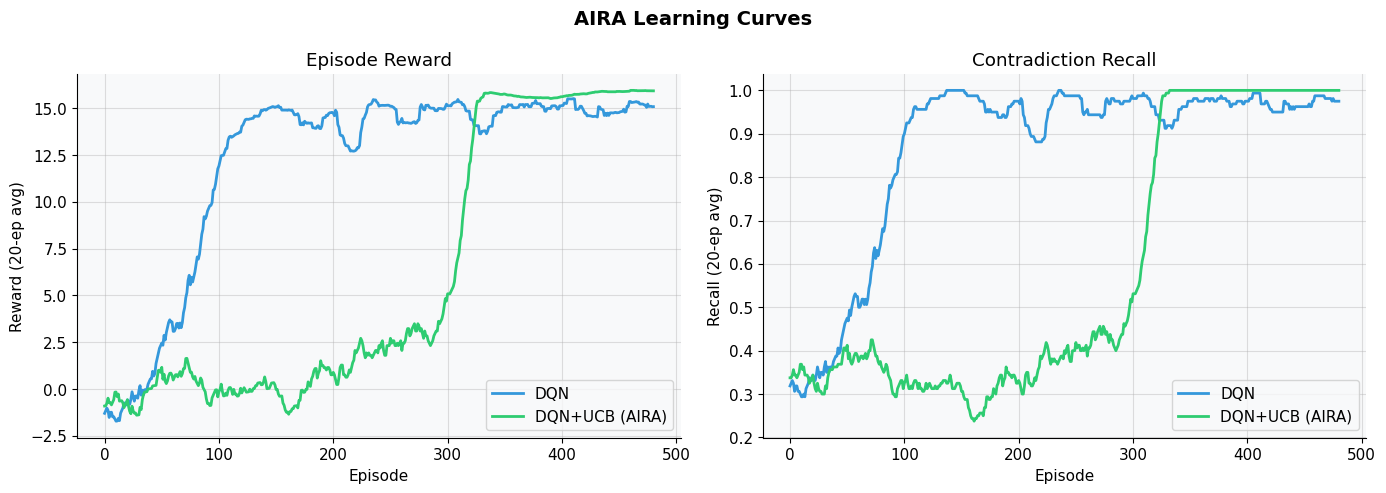

Caption: Training dynamics for DQN and DQN+UCB agents over 500 episodes. UCB exploration accelerates recall convergence.


In [2]:
## Figure 1: Learning Curve (reward over episodes, DQN vs DQN+UCB)
def smooth(data, w=20):
    if not data or len(data) < w:
        return data
    return list(np.convolve(data, np.ones(w)/w, mode='valid'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AIRA Learning Curves', fontsize=14, fontweight='bold')

for key in ('dqn', 'dqn_ucb'):
    r = results[key]
    if r is None: continue
    x = range(len(smooth(r['reward_history'])))
    axes[0].plot(x, smooth(r['reward_history']), label=LABELS[key], color=COLORS[key], lw=2)
    axes[1].plot(x, smooth(r.get('recall_history', [])), label=LABELS[key], color=COLORS[key], lw=2)

axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward (20-ep avg)')
axes[0].set_title('Episode Reward'); axes[0].legend()
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Recall (20-ep avg)')
axes[1].set_title('Contradiction Recall'); axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Caption: Training dynamics for DQN and DQN+UCB agents over 500 episodes. UCB exploration accelerates recall convergence.')

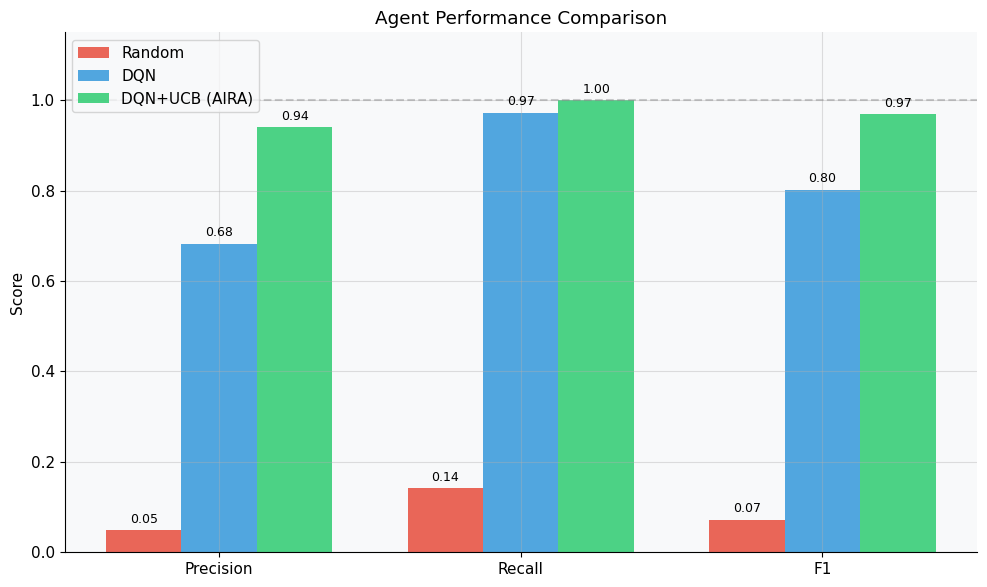

Caption: Precision, Recall, and F1 for each agent averaged over final 50 training episodes.


In [3]:
## Figure 2: Comparison Bar Chart (Precision / Recall / F1 for all 3 agents)
metrics_keys = ['final_precision', 'final_recall', 'final_f1']
metric_labels = ['Precision', 'Recall', 'F1']

agents = ['random', 'dqn', 'dqn_ucb']
x = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, agent in enumerate(agents):
    r = results[agent]
    if r is None: continue
    vals = [r.get(k, 0) for k in metrics_keys]
    bars = ax.bar(x + i * width, vals, width, label=LABELS[agent], color=COLORS[agent], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width); ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score'); ax.set_title('Agent Performance Comparison')
ax.legend(); ax.axhline(1.0, color='gray', ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig('results/figures/comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Caption: Precision, Recall, and F1 for each agent averaged over final 50 training episodes.')

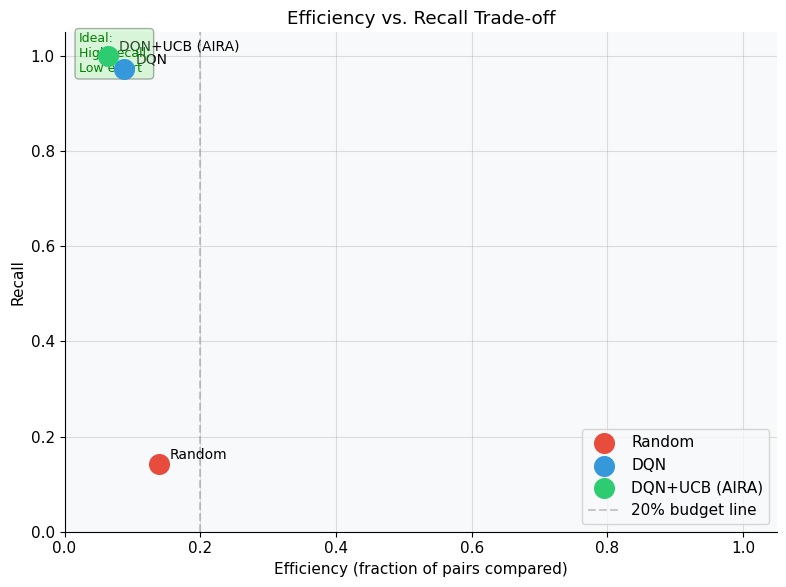

Caption: Efficiency-recall tradeoff. Top-left is ideal: high recall with minimal comparisons.


In [4]:
## Figure 3: Efficiency Tradeoff Scatter
# x = efficiency (pairs compared / total), y = recall
fig, ax = plt.subplots(figsize=(8, 6))

for agent in agents:
    r = results[agent]
    if r is None: continue
    eff = r.get('efficiency_score', 0)
    recall = r.get('final_recall', 0)
    ax.scatter(eff, recall, s=200, color=COLORS[agent], label=LABELS[agent], zorder=5)
    ax.annotate(
        LABELS[agent], (eff, recall),
        textcoords='offset points', xytext=(8, 4), fontsize=10
    )

# Ideal region annotation
ax.axvline(0.20, color='gray', ls='--', alpha=0.4, label='20% budget line')
ax.text(0.02, 0.92, 'Ideal:\nHigh recall,\nLow effort', transform=ax.transAxes,
        fontsize=9, color='green', bbox=dict(boxstyle='round', fc='lightgreen', alpha=0.3))

ax.set_xlabel('Efficiency (fraction of pairs compared)')
ax.set_ylabel('Recall')
ax.set_title('Efficiency vs. Recall Trade-off')
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('results/figures/efficiency_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Caption: Efficiency-recall tradeoff. Top-left is ideal: high recall with minimal comparisons.')

Caption: As training progresses, visit counts accumulate and the UCB bonus decreases, shifting toward exploitation.


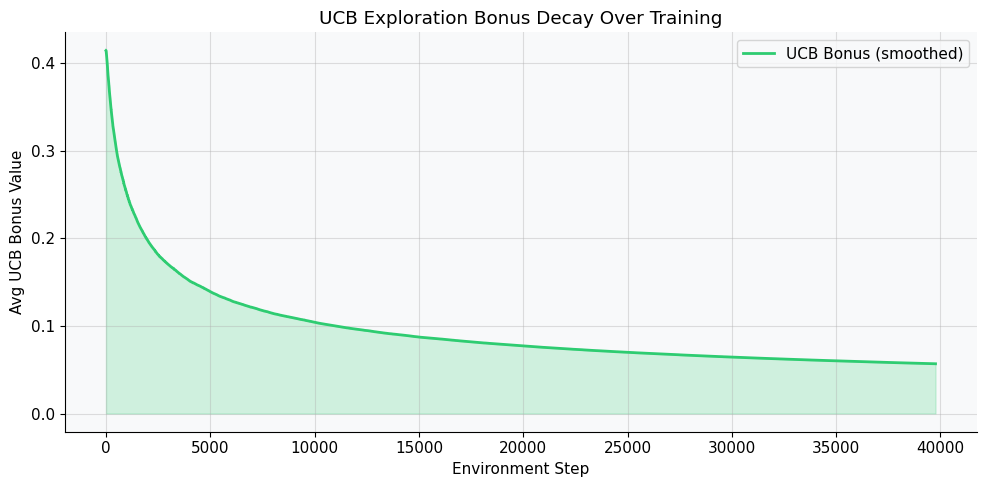

In [5]:
## Figure 4: UCB Bonus Decay (ablation — shows exploration decreasing over training)
fig, ax = plt.subplots(figsize=(10, 5))

if ucb_r and ucb_r.get('ucb_bonus_history'):
    bonus_hist = ucb_r['ucb_bonus_history']
    # Smooth with wider window
    w = max(len(bonus_hist)//50, 10)
    smoothed = np.convolve(bonus_hist, np.ones(w)/w, mode='valid')
    ax.plot(smoothed, color=COLORS['dqn_ucb'], lw=2, label='UCB Bonus (smoothed)')
    ax.fill_between(range(len(smoothed)), smoothed, alpha=0.2, color=COLORS['dqn_ucb'])
    ax.set_xlabel('Environment Step')
    ax.set_ylabel('Avg UCB Bonus Value')
    ax.set_title('UCB Exploration Bonus Decay Over Training')
    ax.legend()
    print('Caption: As training progresses, visit counts accumulate and the UCB bonus decreases, shifting toward exploitation.')
else:
    ax.text(0.5, 0.5, 'UCB bonus history not available\n(run experiment 3 first)',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('results/figures/ucb_bonus_decay.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
## Final Comparison Table
print('\n' + '='*65)
print(f'{"Metric":<25} {"Random":>12} {"DQN":>12} {"DQN+UCB":>12}')
print('-'*65)

for label, key in [
    ('Precision', 'final_precision'),
    ('Recall', 'final_recall'),
    ('F1', 'final_f1'),
    ('Efficiency (lower=better)', 'efficiency_score'),
]:
    vals = [results[a].get(key, 0) if results[a] else 0 for a in agents]
    print(f'{label:<25} {vals[0]:>12.3f} {vals[1]:>12.3f} {vals[2]:>12.3f}')

print('='*65)
print('\nAll figures saved to results/figures/')


Metric                          Random          DQN      DQN+UCB
-----------------------------------------------------------------
Precision                        0.049        0.682        0.940
Recall                           0.142        0.973        1.000
F1                               0.072        0.802        0.969
Efficiency (lower=better)        0.139        0.088        0.064

All figures saved to results/figures/


In [ ]:
## Figure 5: Confusion Matrix — DQN+UCB on Synthetic Policy
from sklearn.metrics import ConfusionMatrixDisplay
import json as _json

# Load annotations to build all-pair ground truth
with open('data/annotated/synthetic_contradictions.json') as f:
    ann = _json.load(f)

# Rebuild env with trained agent for a single eval episode
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.preprocessing.segmenter import segment_policy
from src.preprocessing.embedder import ClauseEmbedder
from src.env.clause_auditor_env import ClauseAuditorEnv
from src.agents.dqn_agent import DQNAgent
from src.agents.ucb_explorer import UCBExplorer
import numpy as np

with open('data/raw/synthetic_policy.txt') as f:
    text = f.read()
clauses = segment_policy(text, 'SYN')
embedder = ClauseEmbedder(cache_dir='data/processed')
embs = embedder.embed_clauses(clauses, doc_name='synthetic_policy')
gt_pairs = {frozenset({c['clause_a'], c['clause_b']}) for c in ann['contradictions']}

env = ClauseAuditorEnv(clauses, embs, gt_pairs, budget_fraction=1.0)  # 100% budget for full coverage

dqn = DQNAgent(state_dim=772, n_actions=2)
ucb = UCBExplorer(dqn, n_pairs=env._n_pairs, c=0.3, warm_start_episodes=0)
ckpt = 'experiments/exp3_dqn_with_ucb/checkpoints/final.pt'
if os.path.exists(ckpt):
    ucb.load(ckpt)
    print(f'Loaded checkpoint: {ckpt}')
else:
    print('WARNING: checkpoint not found, using untrained agent')

# Run one full episode (100% budget = all pairs reviewed)
ucb.reset()
obs, info = env.reset(seed=42)
while True:
    i, j = env._pair_queue[env._queue_idx]
    n = len(env.clauses)
    flat_idx = UCBExplorer.pair_to_idx(min(i, j), max(i, j), n)
    action = ucb.select_action(obs, flat_idx)
    obs, reward, terminated, truncated, step_info = env.step(action)
    if terminated or truncated:
        break

decisions = env.get_decisions()

# Build y_true and y_pred over ALL pairs
pair_to_ids = {frozenset({clauses[i]['id'], clauses[j]['id']}): (i, j) for i, j in env._all_pairs}
y_true, y_pred = [], []
for pair_key in pair_to_ids:
    y_true.append(1 if pair_key in gt_pairs else 0)
    y_pred.append(1 if decisions.get(pair_key) == 1 else 0)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=['Non-contradiction', 'Contradiction'],
    colorbar=False,
    ax=ax,
    cmap='Blues'
)
ax.set_title('Confusion Matrix — DQN+UCB (Full Coverage, Seed 42)', fontsize=11)
plt.tight_layout()
plt.savefig('results/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tp = int((y_true == 1) & (y_pred == 1)).sum()
fp = int((y_true == 0) & (y_pred == 1)).sum()
fn = int((y_true == 1) & (y_pred == 0)).sum()
tn = int((y_true == 0) & (y_pred == 0)).sum()
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'Precision={tp/(tp+fp):.3f}  Recall={tp/(tp+fn):.3f}')

In [ ]:
## Figure 6: Per-Contradiction-Type Breakdown
from src.evaluation.metrics import compute_per_type_metrics

# decisions and annotations already loaded from previous cell
with open('data/annotated/synthetic_contradictions.json') as f:
    ann_data = _json.load(f)

per_type = compute_per_type_metrics(decisions, ann_data['contradictions'])

types = list(per_type.keys())
tp_vals  = [per_type[t]['TP'] for t in types]
fp_vals  = [per_type[t]['FP'] for t in types]
fn_vals  = [per_type[t]['FN'] for t in types]
f1_vals  = [per_type[t]['f1'] for t in types]
recall_vals = [per_type[t]['recall'] for t in types]

x = np.arange(len(types))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Contradiction-Type Performance — DQN+UCB', fontsize=13)

# Left: TP/FP/FN counts
bars_tp = ax1.bar(x - width, tp_vals, width, label='TP', color='#2ecc71', alpha=0.85)
bars_fp = ax1.bar(x,          fp_vals, width, label='FP', color='#e74c3c', alpha=0.85)
bars_fn = ax1.bar(x + width,  fn_vals, width, label='FN', color='#f39c12', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(types, rotation=20, ha='right', fontsize=9)
ax1.set_ylabel('Count')
ax1.set_title('TP / FP / FN by Contradiction Type')
ax1.legend()

# Right: Recall and F1 per type
ax2.bar(x - width/2, recall_vals, width, label='Recall', color='#3498db', alpha=0.85)
ax2.bar(x + width/2, f1_vals,    width, label='F1',     color='#9b59b6', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(types, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1.2)
ax2.set_title('Recall and F1 by Contradiction Type')
ax2.axhline(1.0, color='gray', ls='--', alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.savefig('results/figures/per_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print('
Per-type results:')
print(f'{"Type":<30} {"GT":>5} {"TP":>5} {"FP":>5} {"FN":>5} {"Recall":>8} {"F1":>8}')
print('-' * 75)
for t in types:
    m = per_type[t]
    print(f'{t:<30} {m["total_gt"]:>5} {m["TP"]:>5} {m["FP"]:>5} {m["FN"]:>5} '
          f'{m["recall"]:>8.3f} {m["f1"]:>8.3f}')